This will have the same setup as the churn behaviour notebook

Business question: When do loyal customers shop, and does timing shape retention?

This tells us not just who churns, but when they shop before they churn. If afternoon shoppers in Winter show systematically higher churn, that's a segment-timing intervention we can design right now.

In [ ]:
# ── 00. SETUP ────────────────────────────────────────────────────────


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── 1. GLOBAL STYLE ──────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

FIGSIZE_STD   = (12, 5)   # standard wide chart
FIGSIZE_TALL  = (10, 7)   # for scatter / complex plots
FIGSIZE_PANEL = (14, 6)   # side-by-side panels
DPI           = 130

# Colour palette — consistent across all charts
PALETTE = {
    'churn_high': '#f85149',   # red  — high churn risk
    'churn_low':  '#3fb950',   # green — loyal customers
    'neutral':    '#58a6ff',   # blue  — general insight
    'accent':     '#e3b341',   # gold  — highlight
    'purple':     '#bc8cff',   # purple — secondary
}

# ── 2. LOAD DATA ─────────────────────────────────────────────────────
df = pd.read_csv('../data/customer_churn.csv')

# ── 3. DATE ENGINEERING ──────────────────────────────────────────────
df['Launch_Date']    = pd.to_datetime(df['Launch_Date'])
df['Peak_Sales_Date'] = pd.to_datetime(df['Peak_Sales_Date'])

# How many days from launch to peak performance
df['Days_to_Peak'] = (
    df['Peak_Sales_Date'] - df['Launch_Date']
).dt.days

# How long the product has been live (vs a reference "today")
REFERENCE_DATE = pd.Timestamp('2024-01-01')
df['Product_Age_Days'] = (
    REFERENCE_DATE - df['Launch_Date']
).dt.days

df['Launch_Year']  = df['Launch_Date'].dt.year
df['Launch_Month'] = df['Launch_Date'].dt.month

# ── 4. LIFECYCLE STAGE ENGINEERING ───────────────────────────────────
# Bin customers by purchase frequency into lifecycle stages
df['Lifecycle_Stage'] = pd.cut(
    df['Purchase_Frequency'],
    bins=[0, 3, 7, 12, 20],
    labels=['New', 'Developing', 'Established', 'Loyal']
)

# ── 5. CHURN RISK BANDS ──────────────────────────────────────────────
df['Churn_Risk_Band'] = pd.cut(
    df['Churn_Probability'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# ── 6. ADOPTER TYPE ──────────────────────────────────────────────────
# Early adopters = customers who transacted within 6 months of launch
df['Adopter_Type'] = np.where(
    df['Launch_Year'] <= 2021,
    'Early Adopter',
    'Later User'
)

# ── 7. CUSTOMER MATURITY BAND ────────────────────────────────────────
df['Maturity_Band'] = pd.cut(
    df['Lifetime_Value'],
    bins=[0, 2000, 5000, 10000],
    labels=['Early Value', 'Growth Value', 'Mature Value']
)

# ── 8. OUTPUT FOLDER ─────────────────────────────────────────────────
OUT = Path('../outputs/charts')
OUT.mkdir(parents=True, exist_ok=True)

print(f"✓ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"✓ Output path: {OUT}")
df.head(3)

✓ Dataset loaded: 10,000 rows × 23 cols
✓ Output path: ..\outputs\charts


,Customer_ID,Product_ID,Transaction_ID,Purchase_Frequency,Average_Order_Value,Most_Frequent_Category,Time_Between_Purchases,Region,Churn_Probability,Lifetime_Value,...,Preferred_Purchase_Times,Retention_Strategy,Days_to_Peak,Product_Age_Days,Launch_Year,Launch_Month,Lifecycle_Stage,Churn_Risk_Band,Adopter_Type,Maturity_Band
0,CUST_9HOS83,PROD_IK97D1,TRANS_II1DZG,17,172.57,Electronics,45,South America,0.98,952.81,...,Afternoon,Loyalty Program,1276,1388,2020,3,Loyal,High Risk,Early Adopter,Early Value
1,CUST_AJU17N,PROD_UNN7KP,TRANS_9HJF7I,10,64.89,Clothing,6,South America,0.66,5427.51,...,Afternoon,Discount,79,443,2022,10,Established,Medium Risk,Later User,Mature Value
2,CUST_11XNYF,PROD_0XEW2W,TRANS_OT96OM,3,120.38,Sports,23,Asia,0.60,3994.80,...,Evening,Loyalty Program,492,762,2021,11,New,Medium Risk,Early Adopter,Growth Value


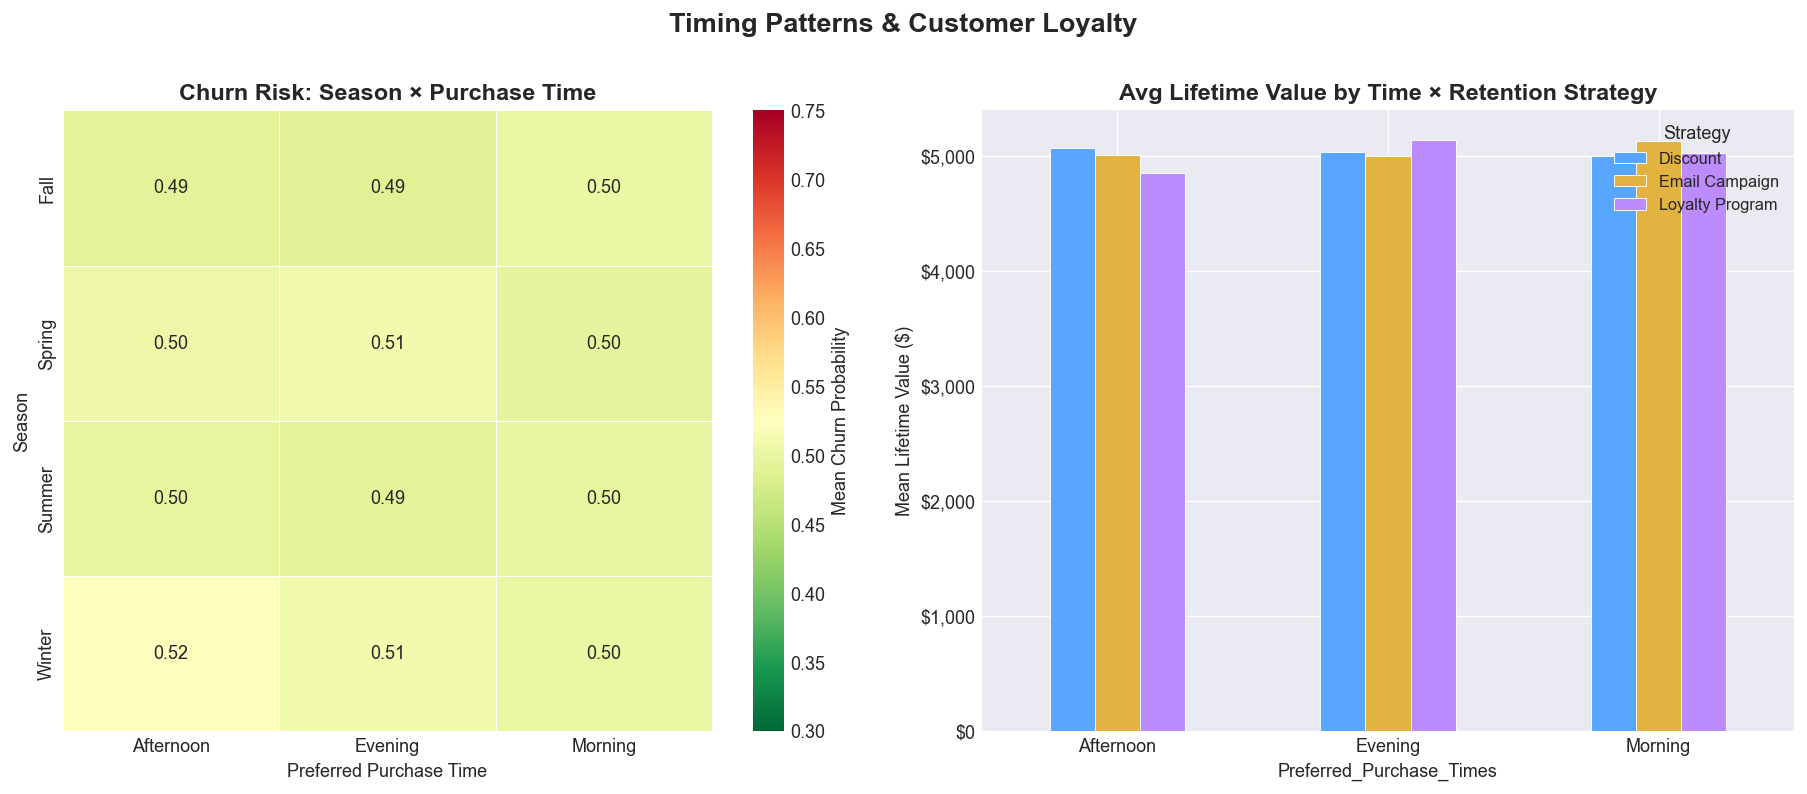

In [2]:
# ── 02. TIMING PATTERNS & LOYALTY ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_PANEL, dpi=DPI)

# LEFT PANEL: Season × Preferred Time → mean churn (heatmap)
pivot_churn = (
    df.groupby(['Season', 'Preferred_Purchase_Times'])['Churn_Probability']
      .mean()
      .unstack('Preferred_Purchase_Times')
)

sns.heatmap(
    pivot_churn,
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',   # red = high churn, green = loyal
    linewidths=0.5,
    vmin=0.3, vmax=0.75,
    ax=axes[0],
    cbar_kws={'label': 'Mean Churn Probability'}
)
axes[0].set_title('Churn Risk: Season × Purchase Time',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Preferred Purchase Time')
axes[0].set_ylabel('Season')

# RIGHT PANEL: Retention strategy effectiveness by preferred time
pivot_ltv = (
    df.groupby(['Preferred_Purchase_Times', 'Retention_Strategy'])
      ['Lifetime_Value'].mean().unstack('Retention_Strategy')
)
pivot_ltv.plot(kind='bar', ax=axes[1],
               color=[PALETTE['neutral'], PALETTE['accent'], PALETTE['purple']],
               edgecolor='white', linewidth=0.5, rot=0)
axes[1].set_title('Avg Lifetime Value by Time × Retention Strategy',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Lifetime Value ($)')
axes[1].legend(title='Strategy', fontsize=9)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Timing Patterns & Customer Loyalty',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT / '02_timing_loyalty.png', bbox_inches='tight')
plt.show()